In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
df = pd.read_csv('/content/drive/MyDrive/Courses/2023 Fall CMPE 257/Colab/Perceptron/synthetic_dataset.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      50 non-null     float64
 1   x2      50 non-null     float64
 2   y       50 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


Prep the dataset with the x0 column

<Axes: xlabel='x1', ylabel='x2'>

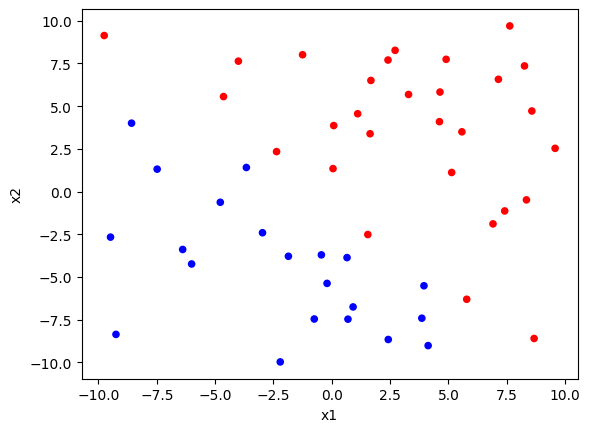

In [22]:
col = df['y'].map({-1:'b', 1:'r'})
df.plot.scatter(x='x1', y='x2', c=col)

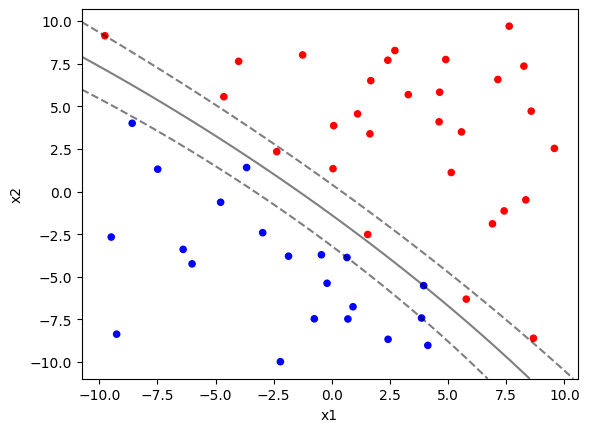

In [31]:
from sklearn import svm

def plot_contours(clf,xx,yy):
    z = clf.predict(np.c_[xx.ravel(),yy.ravel()])
    z = z.reshape(xx.shape)
    out = plt.contour(xx,yy,z)
    return out

x = df[['x1', 'x2']]
y = df['y']
clf = svm.SVC(kernel="rbf", C=100, gamma=0.001)
clf.fit(x,y)

from sklearn.inspection import DecisionBoundaryDisplay

df.plot.scatter(x='x1', y='x2', c=col)
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    x,
    plot_method="contour",
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.5,
    linestyles=["--", "-", "--"],
    ax=ax,
)
# plot support vectors
#ax.scatter(
#    clf.support_vectors_[:, 0],
#    clf.support_vectors_[:, 1],
#    s=100,
#    linewidth=1,
#    facecolors="none",
#    edgecolors="k",
#)
plt.show()